<a href="https://colab.research.google.com/github/saniyaverma/DGFL-for-plant-disease-detection/blob/main/Copy_of_25_OptimisingLabelSmoothing%2BLowerBackbone%2B7Rounds_(Corn%2BTomato_2Heads_50_50fedavg).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment & Global Configuration

In [ ]:
# -------------------------------
# Device Configuration
# -------------------------------

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [ ]:
# -------------------------------
# Reproducibility
# -------------------------------

import os
import random
import numpy as np

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

set_seed(SEED)

print(f"All seeds fixed to {SEED}")

All seeds fixed to 42


In [ ]:
# -------------------------------
# Federated Configuration
# -------------------------------

NUM_CLIENTS_TOMATO = 2
NUM_CLIENTS_CORN = 2
NUM_ROUNDS = 7
LOCAL_EPOCHS = 2
BATCH_SIZE = 32

# -------------------------------
# Model Configuration
# -------------------------------

NUM_TOMATO_CLASSES = 10
NUM_CORN_CLASSES = 4
FEATURE_DIM = 512
PRETRAINED = True

# -------------------------------
# Optimization
# -------------------------------

BASE_LR = 1e-3
BACKBONE_LR_FACTOR = 0.05
CLASSIFIER_LR_FACTOR = 1.0
DISCRIMINATOR_LR_FACTOR = 1.0
WEIGHT_DECAY = 1e-4

# -------------------------------
# Domain Generalization Configuration
# -------------------------------
LAMBDA_CORAL_MAX = 1.0
LAMBDA_DANN_MAX = 0.05
WARMUP = True

BUFFER_SIZE_PER_DOMAIN = 256
BUFFER_RECENT_PER_STEP = 128
BUFFER_RESET_EVERY = 2
RESET_BUFFER_ON_UNFREEZE = True
MIN_CORAL_SAMPLES = 8
COV_EPS = 1e-3

DG_GRAD_CLIP = 2.0
DROP_LAST_TRAIN = True

In [ ]:
# -------------------------------
# Utilities
# -------------------------------

import copy
import math

def get_lambda(round_idx, total_rounds, max_lambda):
    if not WARMUP:
        return max_lambda

    p = (round_idx - 1) / max(1, total_rounds - 1)
    return max_lambda * p

def weighted_fed_avg(models, dataset_sizes):
    global_dict = copy.deepcopy(models[0].state_dict())
    total_samples = sum(dataset_sizes)

    for key in global_dict.keys():
        if global_dict[key].dtype == torch.long:
            global_dict[key] = models[0].state_dict()[key]
        else:
            weighted_sum = 0
            for model, size in zip(models, dataset_sizes):
                weighted_sum += model.state_dict()[key] * (size / total_samples)

            global_dict[key] = weighted_sum

    return global_dict

Kaggle Setup & Dataset Download

In [ ]:
!pip install -q kaggle

In [ ]:
# from google.colab import files

# print("Upload kaggle.json")
# files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured.")

Kaggle API configured.


In [ ]:
!kaggle datasets download -d ashishmotwani/tomato
!kaggle datasets download -d kaustubhb999/tomatoleaf
!kaggle datasets download -d luisolazo/tomato-diseases

!kaggle datasets download -d smaranjitghose/corn-or-maize-leaf-disease-dataset
!kaggle datasets download -d nafishamoin/new-bangladeshi-crop-disease
!kaggle datasets download -d karagwaanntreasure/plant-disease-detection

!unzip -q tomato.zip -d tomato_A
!unzip -q tomatoleaf.zip -d tomato_B
!unzip -q tomato-diseases.zip -d tomato_unseen

!unzip -q corn-or-maize-leaf-disease-dataset.zip -d corn_A
!unzip -q new-bangladeshi-crop-disease.zip -d corn_B
!unzip -q plant-disease-detection.zip -d corn_unseen

print("Datasets extracted.")

Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato
License(s): copyright-authors
100% 1.37G/1.37G [01:38<00:00, 14.9MB/s]

Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
100% 179M/179M [00:14<00:00, 12.9MB/s]

Dataset URL: https://www.kaggle.com/datasets/luisolazo/tomato-diseases
License(s): CC0-1.0
100% 411M/411M [00:23<00:00, 18.3MB/s]

Dataset URL: https://www.kaggle.com/datasets/smaranjitghose/corn-or-maize-leaf-disease-dataset
License(s): copyright-authors
100% 161M/161M [00:11<00:00, 14.5MB/s]

Dataset URL: https://www.kaggle.com/datasets/nafishamoin/new-bangladeshi-crop-disease
License(s): copyright-authors
100% 2.35G/2.35G [02:27<00:00, 17.0MB/s]

Dataset URL: https://www.kaggle.com/datasets/karagwaanntreasure/plant-disease-detection
License(s): MIT
100% 534M/534M [00:30<00:00, 18.4MB/s]

Datasets extracted.


Dataset Preprocessing

In [ ]:
# ============================================================
# Folder Structure Inspection
# ============================================================

def show_tree(path, depth=3):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level < depth:
            print("  " * level + os.path.basename(root))

print("=== Tomato A ===")
show_tree("tomato_A")

print("\n=== Tomato B ===")
show_tree("tomato_B", depth=4)

print("\n=== Tomato Unseen ===")
show_tree("tomato_unseen")

print("\n=== Corn A ===")
show_tree("corn_A", depth=4)

print("\n=== Corn B ===")
show_tree("corn_B", depth=6)

print("\n=== Corn Unseen ===")
show_tree("corn_unseen", depth=5)

=== Tomato A ===
tomato_A
  train
    Septoria_leaf_spot
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Bacterial_spot
    Late_blight
    powdery_mildew
    Spider_mites Two-spotted_spider_mite
    Leaf_Mold
    Tomato_mosaic_virus
    healthy
  valid
    Septoria_leaf_spot
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Bacterial_spot
    Late_blight
    powdery_mildew
    Spider_mites Two-spotted_spider_mite
    Leaf_Mold
    Tomato_mosaic_virus
    healthy

=== Tomato B ===
tomato_B
  tomato
    train
      Tomato___Septoria_leaf_spot
      Tomato___Leaf_Mold
      Tomato___Late_blight
      Tomato___Early_blight
      Tomato___Target_Spot
      Tomato___Tomato_mosaic_virus
      Tomato___healthy
      Tomato___Spider_mites Two-spotted_spider_mite
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
    val
      Tomato___Septoria_leaf_spot
      Tomato___Leaf_Mold
      Tomato___Late_blight
      Tomato___Early_b

In [ ]:
# ============================================================
# Delete the extra class (Tomato)
# ============================================================

import shutil

paths_to_delete = [
    "tomato_A/train/powdery_mildew",
    "tomato_A/valid/powdery_mildew"
]

for p in paths_to_delete:
    if os.path.exists(p):
        shutil.rmtree(p)
        print(f"Deleted: {p}")

Deleted: tomato_A/train/powdery_mildew
Deleted: tomato_A/valid/powdery_mildew


In [ ]:
# ============================================================
# Delete unwanted folders/classes (Corn)
# ============================================================

def safe_rmtree(path):
    if os.path.isdir(path):
        shutil.rmtree(path)
        print(f"Deleted: {path}")

safe_rmtree("corn_B/Invalid")

corn_b_root = "corn_B/BangladeshiCrops/BangladeshiCrops/Crop___Disease"
if os.path.isdir(corn_b_root):
    for name in os.listdir(corn_b_root):
        full = os.path.join(corn_b_root, name)
        if name != "Corn":
            safe_rmtree(full)

corn_unseen_root = "corn_unseen/Dataset"
keep_unseen = {
    "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___healthy",
}

if os.path.isdir(corn_unseen_root):
    for name in os.listdir(corn_unseen_root):
        full = os.path.join(corn_unseen_root, name)
        if name not in keep_unseen:
            safe_rmtree(full)

print("Corn folder cleanup complete.")

Deleted: corn_B/Invalid
Deleted: corn_B/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Rice
Deleted: corn_B/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Potato
Deleted: corn_B/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Wheat
Deleted: corn_unseen/Dataset/Tomato__Tomato_mosaic_virus
Deleted: corn_unseen/Dataset/Tomato_healthy
Deleted: corn_unseen/Dataset/Apple___healthy
Deleted: corn_unseen/Dataset/Apple___Black_rot
Deleted: corn_unseen/Dataset/Tomato_Early_blight
Deleted: corn_unseen/Dataset/Pepper__bell___Bacterial_spot
Deleted: corn_unseen/Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus
Deleted: corn_unseen/Dataset/Tomato_Spider_mites_Two_spotted_spider_mite
Deleted: corn_unseen/Dataset/Potato___Late_blight
Deleted: corn_unseen/Dataset/Pepper__bell___healthy
Deleted: corn_unseen/Dataset/Tomato_Late_blight
Deleted: corn_unseen/Dataset/Tomato_Leaf_Mold
Deleted: corn_unseen/Dataset/Potato___healthy
Deleted: corn_unseen/Dataset/Apple___Cedar_apple_rust
Deleted: corn_unseen/Datas

In [ ]:
# ============================================================
# Inspect folder structures again
# ============================================================

def show_tree(path, depth=3):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level < depth:
            print("  " * level + os.path.basename(root))

print("=== Tomato A ===")
show_tree("tomato_A")

print("\n=== Tomato B ===")
show_tree("tomato_B", depth=4)

print("\n=== Tomato Unseen ===")
show_tree("tomato_unseen")

print("\n=== Corn A ===")
show_tree("corn_A", depth=4)

print("\n=== Corn B ===")
show_tree("corn_B", depth=6)

print("\n=== Corn Unseen ===")
show_tree("corn_unseen", depth=5)

=== Tomato A ===
tomato_A
  train
    Septoria_leaf_spot
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Bacterial_spot
    Late_blight
    Spider_mites Two-spotted_spider_mite
    Leaf_Mold
    Tomato_mosaic_virus
    healthy
  valid
    Septoria_leaf_spot
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Bacterial_spot
    Late_blight
    Spider_mites Two-spotted_spider_mite
    Leaf_Mold
    Tomato_mosaic_virus
    healthy

=== Tomato B ===
tomato_B
  tomato
    train
      Tomato___Septoria_leaf_spot
      Tomato___Leaf_Mold
      Tomato___Late_blight
      Tomato___Early_blight
      Tomato___Target_Spot
      Tomato___Tomato_mosaic_virus
      Tomato___healthy
      Tomato___Spider_mites Two-spotted_spider_mite
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
    val
      Tomato___Septoria_leaf_spot
      Tomato___Leaf_Mold
      Tomato___Late_blight
      Tomato___Early_blight
      Tomato___Target_Spot
     

In [ ]:
# ============================================================
# Dataset Scanning for any missing / corrupt values
# ============================================================

from PIL import Image
import pandas as pd
from tqdm import tqdm

def scan_dataset(root_dir, dataset_name):
    records = []
    broken = []

    for root, dirs, files in os.walk(root_dir):
        dirs.sort()
        files.sort()
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(root, file)
                label = os.path.basename(root)
                try:
                    img = Image.open(path)
                    img.verify()
                    records.append({
                        "dataset": dataset_name,
                        "path": path,
                        "raw_label": label
                    })
                except:
                    broken.append(path)

    print(f"{dataset_name}: {len(records)} valid images")
    print(f"{dataset_name}: {len(broken)} broken images")

    return pd.DataFrame(records)

# ---- Tomato ----
df_A = scan_dataset("tomato_A", "A")
df_B = scan_dataset("tomato_B/tomato", "B")
df_C = scan_dataset("tomato_unseen", "C")

df_tomato = pd.concat([df_A, df_B, df_C]).reset_index(drop=True)

print("Total tomato images:", len(df_tomato))

# ---- Corn ----
df_CA = scan_dataset("corn_A/data", "CA")
df_CB = scan_dataset("corn_B/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Corn", "CB")
df_CU = scan_dataset("corn_unseen/Dataset", "CU")

df_corn = pd.concat([df_CA, df_CB, df_CU]).reset_index(drop=True)

print("Total corn images:", len(df_corn))

A: 31278 valid images
A: 0 broken images
B: 11000 valid images
B: 0 broken images
C: 22193 valid images
C: 0 broken images
Total tomato images: 64471
CA: 4188 valid images
CA: 0 broken images
CB: 3852 valid images
CB: 0 broken images
CU: 7316 valid images
CU: 0 broken images
Total corn images: 15356


Label Harmonization

In [ ]:
# ============================================================
# Canonical Labels
# ============================================================

tomato_labels = [
    "bacterial_spot",
    "early_blight",
    "late_blight",
    "leaf_mold",
    "mosaic_virus",
    "septoria_leaf_spot",
    "spider_mites",
    "target_spot",
    "yellow_leaf_curl_virus",
    "healthy"
]

tomato_label_to_id = {label: idx for idx, label in enumerate(tomato_labels)}
tomato_id_to_label = {idx: label for idx, label in enumerate(tomato_labels)}


corn_labels = [
    "blight",
    "common_rust",
    "gray_leaf_spot",
    "corn_healthy"
]

corn_label_to_id = {label: idx for idx, label in enumerate(corn_labels)}
corn_id_to_label = {idx: label for idx, label in enumerate(corn_labels)}

In [ ]:
# ============================================================
# Dataset-Specific Label Mapping
# ============================================================

mapping_A = {
    "Bacterial_spot": "bacterial_spot",
    "Early_blight": "early_blight",
    "Late_blight": "late_blight",
    "Leaf_Mold": "leaf_mold",
    "Tomato_mosaic_virus": "mosaic_virus",
    "Septoria_leaf_spot": "septoria_leaf_spot",
    "Spider_mites Two-spotted_spider_mite": "spider_mites",
    "Target_Spot": "target_spot",
    "Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",
    "healthy": "healthy"
}

mapping_B = {
    "Tomato___Bacterial_spot": "bacterial_spot",
    "Tomato___Early_blight": "early_blight",
    "Tomato___Late_blight": "late_blight",
    "Tomato___Leaf_Mold": "leaf_mold",
    "Tomato___Tomato_mosaic_virus": "mosaic_virus",
    "Tomato___Septoria_leaf_spot": "septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite": "spider_mites",
    "Tomato___Target_Spot": "target_spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",
    "Tomato___healthy": "healthy"
}

mapping_C = {
    "bacterial_spot": "bacterial_spot",
    "early_blight": "early_blight",
    "late_blight": "late_blight",
    "leaf_mold": "leaf_mold",
    "mosaic_virus": "mosaic_virus",
    "septoria_leaf_spot": "septoria_leaf_spot",
    "twospotted_spider_mite": "spider_mites",
    "target_spot": "target_spot",
    "yellow_leaf_curl_virus": "yellow_leaf_curl_virus",
    "healthy": "healthy"
}

mapping_CA = {
    "Blight": "blight",
    "Common_Rust": "common_rust",
    "Gray_Leaf_Spot": "gray_leaf_spot",
    "Healthy": "corn_healthy"
}

mapping_CB = {
    "Corn___Northern_Leaf_Blight": "blight",
    "Corn___Common_Rust": "common_rust",
    "Corn___Gray_Leaf_Spot": "gray_leaf_spot",
    "Corn___Healthy": "corn_healthy"
}

mapping_CU = {
    "Corn_(maize)___Northern_Leaf_Blight": "blight",
    "Corn_(maize)___Common_rust_": "common_rust",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": "gray_leaf_spot",
    "Corn_(maize)___healthy": "corn_healthy"
}

In [ ]:
# ============================================================
# Apply Harmonization
# ============================================================

def harmonize_tomato(row):
    if row["dataset"] == "A":
        return mapping_A.get(row["raw_label"])
    if row["dataset"] == "B":
        return mapping_B.get(row["raw_label"])
    if row["dataset"] == "C":
        return mapping_C.get(row["raw_label"])

df_tomato["canonical_label"] = df_tomato.apply(harmonize_tomato, axis=1)
df_tomato["class_id"] = df_tomato["canonical_label"].map(tomato_label_to_id)

def harmonize_corn(row):
    if row["dataset"] == "CA":
        return mapping_CA.get(row["raw_label"])
    if row["dataset"] == "CB":
        return mapping_CB.get(row["raw_label"])
    if row["dataset"] == "CU":
        return mapping_CU.get(row["raw_label"])

df_corn["canonical_label"] = df_corn.apply(harmonize_corn, axis=1)
df_corn["class_id"] = df_corn["canonical_label"].map(corn_label_to_id)

# Sanity check
missing_t = df_tomato[df_tomato["canonical_label"].isna()]
print("Missing tomato labels:", missing_t["raw_label"].unique())

missing_c = df_corn[df_corn["canonical_label"].isna()]
print("Missing corn labels:", missing_c["raw_label"].unique())

Missing tomato labels: []
Missing corn labels: []


Client Mapping

In [ ]:
tomato_client_mapping = {
    'A': 0,   # Tomato A
    'B': 1,   # Tomato B
    'C': 2    # Unseen Tomato
}

corn_client_mapping = {
    'CA': 0,  # Corn A
    'CB': 1,  # Corn B
    'CU': 2   # Unseen Corn
}

df_tomato['domain'] = df_tomato['dataset'].map(tomato_client_mapping)
df_corn['domain'] = df_corn['dataset'].map(corn_client_mapping)

In [ ]:
print("\nTomato domain distribution:")
print(df_tomato.groupby(['dataset', 'domain']).size())

print("\nSample dataframe with domain labels:")
df_tomato.head()


Tomato domain distribution:
dataset  domain
A        0         31278
B        1         11000
C        2         22193
dtype: int64

Sample dataframe with domain labels:


,dataset,path,raw_label,canonical_label,class_id,domain
0,A,tomato_A/train/Bacterial_spot/00416648-be6e-4b...,Bacterial_spot,bacterial_spot,0,0
1,A,tomato_A/train/Bacterial_spot/0045ba29-ed1b-43...,Bacterial_spot,bacterial_spot,0,0
2,A,tomato_A/train/Bacterial_spot/00639d29-2d1a-4f...,Bacterial_spot,bacterial_spot,0,0
3,A,tomato_A/train/Bacterial_spot/00728f4d-83a0-49...,Bacterial_spot,bacterial_spot,0,0
4,A,tomato_A/train/Bacterial_spot/00a7c269-3476-4d...,Bacterial_spot,bacterial_spot,0,0


In [ ]:
print("\nCorn domain distribution:")
print(df_corn.groupby(['dataset', 'domain']).size())

print("\nSample dataframe with domain labels:")
df_corn.head()


Corn domain distribution:
dataset  domain
CA       0         4188
CB       1         3852
CU       2         7316
dtype: int64

Sample dataframe with domain labels:


,dataset,path,raw_label,canonical_label,class_id,domain
0,CA,corn_A/data/Blight/Corn_Blight (1).jpeg,Blight,blight,0,0
1,CA,corn_A/data/Blight/Corn_Blight (1).jpg,Blight,blight,0,0
2,CA,corn_A/data/Blight/Corn_Blight (10).jpg,Blight,blight,0,0
3,CA,corn_A/data/Blight/Corn_Blight (100).jpg,Blight,blight,0,0
4,CA,corn_A/data/Blight/Corn_Blight (1000).JPG,Blight,blight,0,0


Client-Wise Train / Val / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

def split_client(df, dataset_id):
    df_client = df[df['dataset'] == dataset_id].reset_index(drop=True)

    df_train, df_temp = train_test_split(
        df_client,
        train_size=0.8,
        stratify=df_client['class_id'],
        random_state=42
    )

    df_val, df_test = train_test_split(
        df_temp,
        train_size=0.5,
        stratify=df_temp['class_id'],
        random_state=42
    )

    return df_train, df_val, df_test

In [ ]:
# ---- Tomato clients ----
df_train_A, df_val_A, df_test_A = split_client(df_tomato, 'A')
df_train_B, df_val_B, df_test_B = split_client(df_tomato, 'B')

# Unseen tomato (use test folder only if present)
df_unseen_tomato = df_tomato[
    (df_tomato['dataset'] == 'C') &
    (df_tomato['path'].str.contains(os.sep + "test" + os.sep))
].reset_index(drop=True)

# Fallback if "test" isn’t in the path
if len(df_unseen_tomato) == 0:
    df_unseen_tomato = df_tomato[df_tomato['dataset'] == 'C'].reset_index(drop=True)

# ---- Corn clients ----
df_train_CA, df_val_CA, df_test_CA = split_client(df_corn, 'CA')
df_train_CB, df_val_CB, df_test_CB = split_client(df_corn, 'CB')

# Unseen corn (entire CU dataset — no train/test split in folder)
df_unseen_corn = df_corn[df_corn['dataset'] == 'CU'].reset_index(drop=True)

print("Tomato A:", len(df_train_A), len(df_val_A), len(df_test_A))
print("Tomato B:", len(df_train_B), len(df_val_B), len(df_test_B))
print("Unseen Tomato:", len(df_unseen_tomato))

print("Corn A:", len(df_train_CA), len(df_val_CA), len(df_test_CA))
print("Corn B:", len(df_train_CB), len(df_val_CB), len(df_test_CB))
print("Unseen Corn:", len(df_unseen_corn))

Tomato A: 25022 3128 3128
Tomato B: 8800 1100 1100
Unseen Tomato: 4440
Corn A: 3350 419 419
Corn B: 3081 385 386
Unseen Corn: 7316


Dataset Class

In [ ]:
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = row['class_id']

        if self.transform:
            image = self.transform(image)

        return image, label

Transforms

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

Dataloaders

In [ ]:
from torch.utils.data import DataLoader

gA = torch.Generator(); gA.manual_seed(SEED)
gB = torch.Generator(); gB.manual_seed(SEED + 1)
gCA = torch.Generator(); gCA.manual_seed(SEED + 2)
gCB = torch.Generator(); gCB.manual_seed(SEED + 3)

# ---- Tomato loaders ----
train_loader_A = DataLoader(
    ImageDataset(df_train_A, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=DROP_LAST_TRAIN,
    generator=gA
)
train_loader_B = DataLoader(
    ImageDataset(df_train_B, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=DROP_LAST_TRAIN,
    generator=gB
)

val_loader_A = DataLoader(ImageDataset(df_val_A, val_transform), batch_size=BATCH_SIZE)
val_loader_B = DataLoader(ImageDataset(df_val_B, val_transform), batch_size=BATCH_SIZE)

test_loader_A = DataLoader(ImageDataset(df_test_A, val_transform), batch_size=BATCH_SIZE)
test_loader_B = DataLoader(ImageDataset(df_test_B, val_transform), batch_size=BATCH_SIZE)

unseen_tomato_loader = DataLoader(ImageDataset(df_unseen_tomato, val_transform), batch_size=BATCH_SIZE)

# ---- Corn loaders ----
train_loader_CA = DataLoader(
    ImageDataset(df_train_CA, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=DROP_LAST_TRAIN,
    generator=gCA
)
train_loader_CB = DataLoader(
    ImageDataset(df_train_CB, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=DROP_LAST_TRAIN,
    generator=gCB
)

val_loader_CA = DataLoader(ImageDataset(df_val_CA, val_transform), batch_size=BATCH_SIZE)
val_loader_CB = DataLoader(ImageDataset(df_val_CB, val_transform), batch_size=BATCH_SIZE)

test_loader_CA = DataLoader(ImageDataset(df_test_CA, val_transform), batch_size=BATCH_SIZE)
test_loader_CB = DataLoader(ImageDataset(df_test_CB, val_transform), batch_size=BATCH_SIZE)

unseen_corn_loader = DataLoader(ImageDataset(df_unseen_corn, val_transform), batch_size=BATCH_SIZE)

Domain Distribution per Dataset

In [ ]:
client_dataset_sizes = [
    len(df_train_A), len(df_train_B),
    len(df_train_CA), len(df_train_CB)
]

print("Client dataset sizes:", client_dataset_sizes)

Client dataset sizes: [25022, 8800, 3350, 3081]


Global Model

In [ ]:
# ============================================================
# Feature Extractor — ResNet18 (ImageNet pretrained)
# ============================================================

import torch.nn as nn
from torchvision import models

class FeatureExtractor(nn.Module):

    def __init__(self, pretrained=True):
        super(FeatureExtractor, self).__init__()

        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT if pretrained else None
        )

        self.backbone.fc = nn.Identity()

    def freeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_layer4(self):
        for name, param in self.backbone.named_parameters():
            if "layer4" in name:
                param.requires_grad = True

    def unfreeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

Task Specific Head

In [ ]:
# ============================================================
# Classifier Head
# ============================================================

class Classifier(nn.Module):
    def __init__(self, in_dim=FEATURE_DIM, num_classes=10):
        super(Classifier, self).__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, features):
        return self.fc(features)

Client Model (Feature Extractor + Classifier)

In [ ]:
class ClientModel(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(ClientModel, self).__init__()

        self.feature_extractor = FeatureExtractor(pretrained=pretrained)
        self.classifier = Classifier(num_classes=num_classes)

    def forward(self, x):
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return logits, features

Domain Generalization Components (CORAL + DANN)

In [ ]:
# ============================================================
# CORAL Loss
# ============================================================

def stable_coral_loss(source, target, eps=COV_EPS):
    if source.size(0) < 2 or target.size(0) < 2:
        return torch.zeros((), device=source.device, dtype=source.dtype)

    d = source.size(1)
    source = source - source.mean(dim=0, keepdim=True)
    target = target - target.mean(dim=0, keepdim=True)

    cov_source = (source.T @ source) / (source.size(0) - 1)
    cov_target = (target.T @ target) / (target.size(0) - 1)

    eye = torch.eye(d, device=source.device, dtype=source.dtype)
    cov_source = cov_source + eps * eye
    cov_target = cov_target + eps * eye

    loss = torch.norm(cov_source - cov_target, p='fro') ** 2
    return loss / (4 * d * d)

In [ ]:
# ============================================================
# Feature Buffer
# ============================================================

class FeatureBuffer:
    def __init__(self, max_size, feature_dim):
        self.max_size = max_size
        self.feature_dim = feature_dim
        self.buffer = torch.empty((0, feature_dim), device=device)

    def add(self, features):
        self.buffer = torch.cat([self.buffer, features.detach()], dim=0)
        if self.buffer.size(0) > self.max_size:
            self.buffer = self.buffer[-self.max_size:]

    def get_recent(self, n):
        if self.buffer.size(0) == 0:
            return self.buffer
        n = min(n, self.buffer.size(0))
        return self.buffer[-n:]

In [ ]:
# ============================================================
# Domain Discriminator
# ============================================================

class DomainDiscriminator(nn.Module):
    def __init__(self, feature_dim=FEATURE_DIM, hidden_dim=256, num_domains=2):
        super(DomainDiscriminator, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_domains)
        )

    def forward(self, features, alpha):
        reversed_features = GradReverse.apply(features, alpha)
        return self.net(reversed_features)

In [ ]:
# ============================================================
# Gradient Reversal Layer
# ============================================================

from torch.autograd import Function

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

In [ ]:
# ============================================================
# Server DG Module
# ============================================================

import torch.optim as optim

class ServerDG:
    def __init__(self, num_domains=2):
        self.domain_discriminator = DomainDiscriminator(num_domains=num_domains).to(device)
        self.criterion_domain = nn.CrossEntropyLoss()

        self.optimizer_dd = optim.Adam(
            self.domain_discriminator.parameters(),
            lr=BASE_LR * DISCRIMINATOR_LR_FACTOR,
            weight_decay=WEIGHT_DECAY
        )

        self.reset_buffers()

    def reset_buffers(self):
        self.buffers = {
            0: FeatureBuffer(BUFFER_SIZE_PER_DOMAIN, FEATURE_DIM),
            1: FeatureBuffer(BUFFER_SIZE_PER_DOMAIN, FEATURE_DIM)
        }

    def compute_dg_grads(self, features_A, features_B, lambda_coral, lambda_dann, alpha):
        hist_A = self.buffers[0].get_recent(BUFFER_RECENT_PER_STEP)
        hist_B = self.buffers[1].get_recent(BUFFER_RECENT_PER_STEP)

        if hist_A.size(0) >= MIN_CORAL_SAMPLES and hist_B.size(0) >= MIN_CORAL_SAMPLES:
            combined_A = torch.cat([hist_A, features_A], dim=0)
            combined_B = torch.cat([hist_B, features_B], dim=0)
            loss_coral_hist = stable_coral_loss(combined_A, combined_B)
            loss_coral_curr = stable_coral_loss(features_A, features_B)
            loss_coral = 0.3 * loss_coral_hist + 0.7 * loss_coral_curr
        else:
            loss_coral = stable_coral_loss(features_A, features_B)

        domain_labels_A = torch.zeros(features_A.size(0), dtype=torch.long, device=device)
        domain_labels_B = torch.ones(features_B.size(0), dtype=torch.long, device=device)

        preds_A = self.domain_discriminator(features_A, alpha)
        preds_B = self.domain_discriminator(features_B, alpha)

        loss_dann_feature = (
            self.criterion_domain(preds_A, domain_labels_A) +
            self.criterion_domain(preds_B, domain_labels_B)
        ) / 2

        dg_loss = lambda_coral * loss_coral + lambda_dann * loss_dann_feature

        grad_A = torch.zeros_like(features_A)
        grad_B = torch.zeros_like(features_B)

        grad_inputs, grad_tags = [], []
        if features_A.requires_grad:
            grad_inputs.append(features_A)
            grad_tags.append("A")
        if features_B.requires_grad:
            grad_inputs.append(features_B)
            grad_tags.append("B")

        if grad_inputs:
            grads = torch.autograd.grad(
                outputs=dg_loss,
                inputs=grad_inputs,
                retain_graph=False,
                create_graph=False,
                allow_unused=True
            )
            for tag, g in zip(grad_tags, grads):
                if g is None:
                    continue
                if tag == "A":
                    grad_A = g.detach()
                else:
                    grad_B = g.detach()

        preds_A_det = self.domain_discriminator(features_A.detach(), alpha=0.0)
        preds_B_det = self.domain_discriminator(features_B.detach(), alpha=0.0)

        loss_dann_disc = (
            self.criterion_domain(preds_A_det, domain_labels_A) +
            self.criterion_domain(preds_B_det, domain_labels_B)
        ) / 2

        self.buffers[0].add(features_A)
        self.buffers[1].add(features_B)

        stats = {
            "dg_loss": dg_loss.detach(),
            "loss_coral": loss_coral.detach(),
            "loss_dann_feature": loss_dann_feature.detach(),
            "loss_dann_disc": loss_dann_disc
        }

        return grad_A, grad_B, stats

Federated Training Loop

In [ ]:
# ============================================================
# Client Training Module
# ============================================================

class ClientTrainer:
    def __init__(self, model, dataloader):
        self.model = model
        self.dataloader = dataloader
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        self.model.feature_extractor.freeze_all()
        self.optimizer = self.get_optimizer()

    def get_optimizer(self):

        backbone_params = []
        classifier_params = []

        for name, param in self.model.named_parameters():

            if param.requires_grad:
                if "feature_extractor" in name:
                    backbone_params.append(param)
                elif "classifier" in name:
                    classifier_params.append(param)

        optimizer = optim.Adam(
            [
                {"params": backbone_params, "lr": BASE_LR * BACKBONE_LR_FACTOR},
                {"params": classifier_params, "lr": BASE_LR * CLASSIFIER_LR_FACTOR}
            ],
            weight_decay=WEIGHT_DECAY
        )

        return optimizer

    def unfreeze_layer4(self):
        print("Unfreezing layer4...")
        self.model.feature_extractor.unfreeze_layer4()
        self.optimizer = self.get_optimizer()

    def unfreeze_all(self):
        print("Unfreezing full backbone...")
        self.model.feature_extractor.unfreeze_all()
        self.optimizer = self.get_optimizer()

    def train_step(self, images, labels, dg_loss):

        self.model.train()
        self.optimizer.zero_grad()

        logits, features = self.model(images)

        task_loss = self.criterion(logits, labels)
        total_loss = task_loss + dg_loss

        total_loss.backward()
        self.optimizer.step()

        return features, task_loss

In [ ]:
# ============================================================
# Initialize Global Model + Clients + Servers
# ============================================================

# Shared backbone weights
global_backbone = FeatureExtractor(pretrained=PRETRAINED).to(device)

# Tomato clients (10-class heads)
tomato_model_A = ClientModel(num_classes=NUM_TOMATO_CLASSES, pretrained=PRETRAINED).to(device)
tomato_model_B = ClientModel(num_classes=NUM_TOMATO_CLASSES, pretrained=PRETRAINED).to(device)

# Corn clients (4-class heads)
corn_model_A = ClientModel(num_classes=NUM_CORN_CLASSES, pretrained=PRETRAINED).to(device)
corn_model_B = ClientModel(num_classes=NUM_CORN_CLASSES, pretrained=PRETRAINED).to(device)

# Sync all client backbones with the global backbone
tomato_model_A.feature_extractor.load_state_dict(global_backbone.state_dict())
tomato_model_B.feature_extractor.load_state_dict(global_backbone.state_dict())
corn_model_A.feature_extractor.load_state_dict(global_backbone.state_dict())
corn_model_B.feature_extractor.load_state_dict(global_backbone.state_dict())

# Two DG servers
server_dg_tomato = ServerDG(num_domains=2)
server_dg_corn   = ServerDG(num_domains=2)

# Client trainers
client_A = ClientTrainer(tomato_model_A, train_loader_A)
client_B = ClientTrainer(tomato_model_B, train_loader_B)

client_CA = ClientTrainer(corn_model_A, train_loader_CA)
client_CB = ClientTrainer(corn_model_B, train_loader_CB)

print("Backbone frozen. Training classifier only.")
print("All components initialized successfully.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


Backbone frozen. Training classifier only.
All components initialized successfully.


In [ ]:
# ============================================================
# Validation Function
# ============================================================

def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits, _ = model(images)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

In [ ]:
# ============================================================
# FedAvg (Crop-balanced Backbone Aggregation)
# ============================================================

def fedavg_backbone(models, dataset_sizes):

    assert len(models) == 4
    assert len(dataset_sizes) == 4

    tA, tB, cA, cB = models
    nA, nB, nCA, nCB = dataset_sizes

    tomato_total = nA + nB
    corn_total = nCA + nCB

    avg_state = copy.deepcopy(tA.feature_extractor.state_dict())

    for k in avg_state.keys():

        if avg_state[k].dtype == torch.long:
            avg_state[k] = tA.feature_extractor.state_dict()[k]
            continue

        tomato_avg = (
            tA.feature_extractor.state_dict()[k] * (nA / tomato_total) +
            tB.feature_extractor.state_dict()[k] * (nB / tomato_total)
        )

        corn_avg = (
            cA.feature_extractor.state_dict()[k] * (nCA / corn_total) +
            cB.feature_extractor.state_dict()[k] * (nCB / corn_total)
        )

        avg_state[k] = 0.5 * tomato_avg + 0.5 * corn_avg

    return avg_state

In [38]:
# ============================================================
# Training Loop
# ============================================================

best_score = -1.0
best_backbone_state = None
best_tomato_heads = None
best_corn_heads = None

for round_idx in range(1, NUM_ROUNDS + 1):
    print(f"\n================ ROUND {round_idx}/{NUM_ROUNDS} ================")

    # Unfreeze schedule (apply to all clients)
    if round_idx == 2:
        client_A.unfreeze_layer4()
        client_B.unfreeze_layer4()
        client_CA.unfreeze_layer4()
        client_CB.unfreeze_layer4()
        if RESET_BUFFER_ON_UNFREEZE:
            server_dg_tomato.reset_buffers()
            server_dg_corn.reset_buffers()

    if round_idx == 4:
        client_A.unfreeze_all()
        client_B.unfreeze_all()
        client_CA.unfreeze_all()
        client_CB.unfreeze_all()
        if RESET_BUFFER_ON_UNFREEZE:
            server_dg_tomato.reset_buffers()
            server_dg_corn.reset_buffers()

    if BUFFER_RESET_EVERY is not None and round_idx % BUFFER_RESET_EVERY == 0:
        print(f"Resetting feature buffers at round {round_idx}")
        server_dg_tomato.reset_buffers()
        server_dg_corn.reset_buffers()

    lambda_coral = get_lambda(round_idx, NUM_ROUNDS, LAMBDA_CORAL_MAX)
    lambda_dann  = get_lambda(round_idx, NUM_ROUNDS, LAMBDA_DANN_MAX)

    p = (round_idx - 1) / max(1, NUM_ROUNDS - 1)
    alpha = 2 / (1 + math.exp(-10 * p)) - 1

    print(f"λ_CORAL: {lambda_coral:.4f} | λ_DANN: {lambda_dann:.4f} | alpha: {alpha:.4f}")

    for local_epoch in range(LOCAL_EPOCHS):
        print(f"\n--- Local Epoch {local_epoch+1}/{LOCAL_EPOCHS} ---")

        # Tomato training (A,B)
        tomato_model_A.train()
        tomato_model_B.train()

        total_ce_A = total_ce_B = total_dg = total_disc = 0.0

        iterator_A = iter(train_loader_A)
        iterator_B = iter(train_loader_B)
        num_steps = max(len(train_loader_A), len(train_loader_B))

        for _ in range(num_steps):
            try:
                images_A, labels_A = next(iterator_A)
            except StopIteration:
                iterator_A = iter(train_loader_A)
                images_A, labels_A = next(iterator_A)

            try:
                images_B, labels_B = next(iterator_B)
            except StopIteration:
                iterator_B = iter(train_loader_B)
                images_B, labels_B = next(iterator_B)

            images_A, labels_A = images_A.to(device), labels_A.to(device)
            images_B, labels_B = images_B.to(device), labels_B.to(device)

            client_A.optimizer.zero_grad(set_to_none=True)
            client_B.optimizer.zero_grad(set_to_none=True)

            logits_A, features_A = tomato_model_A(images_A)
            loss_A = client_A.criterion(logits_A, labels_A)

            logits_B, features_B = tomato_model_B(images_B)
            loss_B = client_B.criterion(logits_B, labels_B)

            dg_grad_A, dg_grad_B, dg_stats = server_dg_tomato.compute_dg_grads(
                features_A, features_B, lambda_coral, lambda_dann, alpha
            )

            dg_grad_A = torch.nan_to_num(dg_grad_A, nan=0.0, posinf=0.0, neginf=0.0).clamp(-DG_GRAD_CLIP, DG_GRAD_CLIP)
            dg_grad_B = torch.nan_to_num(dg_grad_B, nan=0.0, posinf=0.0, neginf=0.0).clamp(-DG_GRAD_CLIP, DG_GRAD_CLIP)

            loss_A.backward(retain_graph=True)
            if features_A.requires_grad:
                features_A.backward(dg_grad_A)

            loss_B.backward(retain_graph=True)
            if features_B.requires_grad:
                features_B.backward(dg_grad_B)

            client_A.optimizer.step()
            client_B.optimizer.step()

            server_dg_tomato.optimizer_dd.zero_grad(set_to_none=True)
            dg_stats["loss_dann_disc"].backward()
            server_dg_tomato.optimizer_dd.step()

            total_ce_A += loss_A.item()
            total_ce_B += loss_B.item()
            total_dg += dg_stats["dg_loss"].item()
            total_disc += dg_stats["loss_dann_disc"].item()

        val_acc_A = evaluate_accuracy(tomato_model_A, val_loader_A)
        val_acc_B = evaluate_accuracy(tomato_model_B, val_loader_B)

        print(
            f"Tomato A - CE: {total_ce_A/num_steps:.4f} | "
            f"Tomato B - CE: {total_ce_B/num_steps:.4f} | "
            f"DG: {total_dg/num_steps:.4f} | "
            f"Disc: {total_disc/num_steps:.4f} | "
            f"Val A: {val_acc_A:.2f}% | Val B: {val_acc_B:.2f}%"
        )

        # Corn training (CA,CB)
        corn_model_A.train()
        corn_model_B.train()

        total_ce_CA = total_ce_CB = total_dg_c = total_disc_c = 0.0

        iterator_CA = iter(train_loader_CA)
        iterator_CB = iter(train_loader_CB)
        num_steps_c = max(len(train_loader_CA), len(train_loader_CB))

        for _ in range(num_steps_c):
            try:
                images_CA, labels_CA = next(iterator_CA)
            except StopIteration:
                iterator_CA = iter(train_loader_CA)
                images_CA, labels_CA = next(iterator_CA)

            try:
                images_CB, labels_CB = next(iterator_CB)
            except StopIteration:
                iterator_CB = iter(train_loader_CB)
                images_CB, labels_CB = next(iterator_CB)

            images_CA, labels_CA = images_CA.to(device), labels_CA.to(device)
            images_CB, labels_CB = images_CB.to(device), labels_CB.to(device)

            client_CA.optimizer.zero_grad(set_to_none=True)
            client_CB.optimizer.zero_grad(set_to_none=True)

            logits_CA, features_CA = corn_model_A(images_CA)
            loss_CA = client_CA.criterion(logits_CA, labels_CA)

            logits_CB, features_CB = corn_model_B(images_CB)
            loss_CB = client_CB.criterion(logits_CB, labels_CB)

            dg_grad_CA, dg_grad_CB, dg_stats_c = server_dg_corn.compute_dg_grads(
                features_CA, features_CB, lambda_coral, lambda_dann, alpha
            )

            dg_grad_CA = torch.nan_to_num(dg_grad_CA, nan=0.0, posinf=0.0, neginf=0.0).clamp(-DG_GRAD_CLIP, DG_GRAD_CLIP)
            dg_grad_CB = torch.nan_to_num(dg_grad_CB, nan=0.0, posinf=0.0, neginf=0.0).clamp(-DG_GRAD_CLIP, DG_GRAD_CLIP)

            loss_CA.backward(retain_graph=True)
            if features_CA.requires_grad:
                features_CA.backward(dg_grad_CA)

            loss_CB.backward(retain_graph=True)
            if features_CB.requires_grad:
                features_CB.backward(dg_grad_CB)

            client_CA.optimizer.step()
            client_CB.optimizer.step()

            server_dg_corn.optimizer_dd.zero_grad(set_to_none=True)
            dg_stats_c["loss_dann_disc"].backward()
            server_dg_corn.optimizer_dd.step()

            total_ce_CA += loss_CA.item()
            total_ce_CB += loss_CB.item()
            total_dg_c += dg_stats_c["dg_loss"].item()
            total_disc_c += dg_stats_c["loss_dann_disc"].item()

        val_acc_CA = evaluate_accuracy(corn_model_A, val_loader_CA)
        val_acc_CB = evaluate_accuracy(corn_model_B, val_loader_CB)

        print(
            f"Corn A - CE: {total_ce_CA/num_steps_c:.4f} | "
            f"Corn B - CE: {total_ce_CB/num_steps_c:.4f} | "
            f"DG: {total_dg_c/num_steps_c:.4f} | "
            f"Disc: {total_disc_c/num_steps_c:.4f} | "
            f"Val A: {val_acc_CA:.2f}% | Val B: {val_acc_CB:.2f}%"
        )

    # Backbone-only FedAvg
    global_backbone_state = fedavg_backbone(
        [tomato_model_A, tomato_model_B, corn_model_A, corn_model_B],
        client_dataset_sizes
    )

    # Broadcast updated backbone to all clients
    tomato_model_A.feature_extractor.load_state_dict(global_backbone_state)
    tomato_model_B.feature_extractor.load_state_dict(global_backbone_state)
    corn_model_A.feature_extractor.load_state_dict(global_backbone_state)
    corn_model_B.feature_extractor.load_state_dict(global_backbone_state)

    print("\nFedAvg backbone complete.")

    # Server-side validation (correct head per crop)
    tA = evaluate_accuracy(tomato_model_A, val_loader_A)
    tB = evaluate_accuracy(tomato_model_B, val_loader_B)
    cA = evaluate_accuracy(corn_model_A, val_loader_CA)
    cB = evaluate_accuracy(corn_model_B, val_loader_CB)

    global_score = (tA + tB + cA + cB) / 4
    print(f"Global Val - Tomato A: {tA:.2f}% | Tomato B: {tB:.2f}% | Corn A: {cA:.2f}% | Corn B: {cB:.2f}% | Avg: {global_score:.2f}%")

    if global_score > best_score:
        best_score = global_score
        best_backbone_state = copy.deepcopy(global_backbone_state)
        best_tomato_heads = (
            copy.deepcopy(tomato_model_A.classifier.state_dict()),
            copy.deepcopy(tomato_model_B.classifier.state_dict())
        )
        best_corn_heads = (
            copy.deepcopy(corn_model_A.classifier.state_dict()),
            copy.deepcopy(corn_model_B.classifier.state_dict())
        )
        print(f"New best global checkpoint saved (Avg Val={best_score:.2f}%).")


================ ROUND 1/7 ================
λ_CORAL: 0.0000 | λ_DANN: 0.0000 | alpha: 0.0000

--- Local Epoch 1/2 ---
Tomato A - CE: 1.4186 | Tomato B - CE: 1.2089 | DG: 0.0000 | Disc: 0.5525 | Val A: 55.40% | Val B: 60.27%
Corn A - CE: 0.8501 | Corn B - CE: 0.7569 | DG: 0.0000 | Disc: 0.7036 | Val A: 76.37% | Val B: 87.01%

--- Local Epoch 2/2 ---
Tomato A - CE: 1.1626 | Tomato B - CE: 0.9453 | DG: 0.0000 | Disc: 0.4762 | Val A: 55.72% | Val B: 62.64%
Corn A - CE: 0.5813 | Corn B - CE: 0.5023 | DG: 0.0000 | Disc: 0.6929 | Val A: 83.77% | Val B: 83.64%

FedAvg backbone complete.
Global Val - Tomato A: 56.75% | Tomato B: 59.45% | Corn A: 80.19% | Corn B: 84.16% | Avg: 70.14%
New best global checkpoint saved (Avg Val=70.14%).

================ ROUND 2/7 ================
Unfreezing layer4...
Unfreezing layer4...
Unfreezing layer4...
Unfreezing layer4...
Resetting feature buffers at round 2
λ_CORAL: 0.1667 | λ_DANN: 0.0083 | alpha: 0.6823

--- Local Epoch 1/2 ---
Tomato A - CE: 0.8763 | T

Evaluation

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F

def evaluate_model(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits, _ = model(images)
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    # Classification report
    cls_report = classification_report(all_labels, all_preds, digits=4)

    # Confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_preds)

    # AUROC (multi-class)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    except:
        auc = None

    return cls_report, conf_matrix, auc

In [40]:
# Confusion Matrix Visualization
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(conf_matrix, title, id_to_label):
    plt.figure(figsize=(8,6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=list(id_to_label.values()),
        yticklabels=list(id_to_label.values())
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

In [41]:
# =========================
# Load best backbone and classifier
# =========================

if best_backbone_state is not None:
    tomato_model_A.feature_extractor.load_state_dict(best_backbone_state)
    tomato_model_B.feature_extractor.load_state_dict(best_backbone_state)
    corn_model_A.feature_extractor.load_state_dict(best_backbone_state)
    corn_model_B.feature_extractor.load_state_dict(best_backbone_state)

    print(f"Loaded best global backbone (Avg Val={best_score:.2f}%) for final testing.")

if best_tomato_heads is not None:
    tomato_model_A.classifier.load_state_dict(best_tomato_heads[0])
    tomato_model_B.classifier.load_state_dict(best_tomato_heads[1])

    print("Loaded best tomato heads.")

if best_corn_heads is not None:
    corn_model_A.classifier.load_state_dict(best_corn_heads[0])
    corn_model_B.classifier.load_state_dict(best_corn_heads[1])

    print("Loaded best corn heads.")

Loaded best global backbone (Avg Val=95.83%) for final testing.
Loaded best tomato heads.
Loaded best corn heads.


In [42]:
# =========================
# Build ensemble heads (average of A and B)
# =========================

def average_heads(headA, headB, wA=0.5, wB=0.5):
    avg_state = {}
    sdA = headA.state_dict()
    sdB = headB.state_dict()
    for k in sdA:
        avg_state[k] = sdA[k] * wA + sdB[k] * wB
    return avg_state

# Weights based on train sizes (you can also use 0.5 / 0.5)
wA = len(df_train_A) / (len(df_train_A) + len(df_train_B))
wB = 1.0 - wA

wCA = len(df_train_CA) / (len(df_train_CA) + len(df_train_CB))
wCB = 1.0 - wCA

# Tomato ensemble head
tomato_ensemble_head = Classifier(num_classes=NUM_TOMATO_CLASSES).to(device)
tomato_ensemble_head.load_state_dict(
    average_heads(tomato_model_A.classifier, tomato_model_B.classifier, wA, wB)
)

# Corn ensemble head
corn_ensemble_head = Classifier(num_classes=NUM_CORN_CLASSES).to(device)
corn_ensemble_head.load_state_dict(
    average_heads(corn_model_A.classifier, corn_model_B.classifier, wCA, wCB)
)

<All keys matched successfully>

Tomato Evaluation


================ TOMATO CLIENT A TEST ================
              precision    recall  f1-score   support

           0     0.9820    0.9185    0.9492       356
           1     0.9410    0.9258    0.9333       310
           2     0.9312    0.9718    0.9511       390
           3     0.9848    0.9284    0.9558       349
           4     0.9597    0.9562    0.9580       274
           5     0.9086    0.8760    0.8920       363
           6     0.9301    0.9771    0.9530       218
           7     0.8143    0.9956    0.8959       229
           8     0.9960    0.9882    0.9921       254
           9     0.9838    0.9455    0.9642       385

    accuracy                         0.9441      3128
   macro avg     0.9431    0.9483    0.9445      3128
weighted avg     0.9469    0.9441    0.9444      3128

AUROC: 0.99781756951967


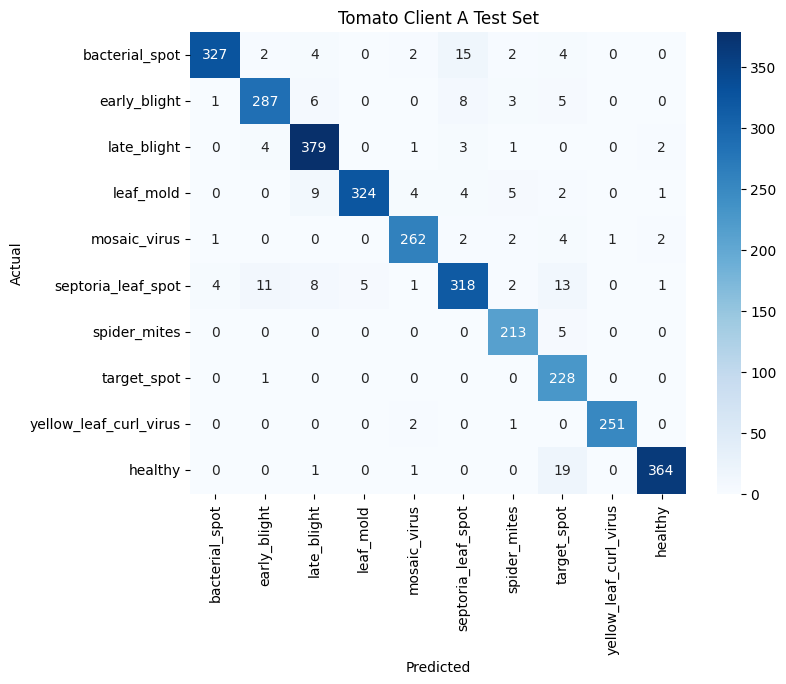

In [43]:
print("\n================ TOMATO CLIENT A TEST ================")

report_A, conf_A, auc_A = evaluate_model(tomato_model_A, test_loader_A)

print(report_A)
print("AUROC:", auc_A)

plot_confusion_matrix(conf_A, "Tomato Client A Test Set", tomato_id_to_label)


================ TOMATO CLIENT B TEST ================
              precision    recall  f1-score   support

           0     0.9732    0.9909    0.9820       110
           1     1.0000    0.7909    0.8832       110
           2     0.9633    0.9545    0.9589       110
           3     0.9541    0.9455    0.9498       110
           4     0.9478    0.9909    0.9689       110
           5     0.9906    0.9545    0.9722       110
           6     0.9550    0.9636    0.9593       110
           7     0.7267    0.9909    0.8385       110
           8     1.0000    0.9818    0.9908       110
           9     1.0000    0.8455    0.9163       110

    accuracy                         0.9409      1100
   macro avg     0.9511    0.9409    0.9420      1100
weighted avg     0.9511    0.9409    0.9420      1100

AUROC: 0.9987612488521579


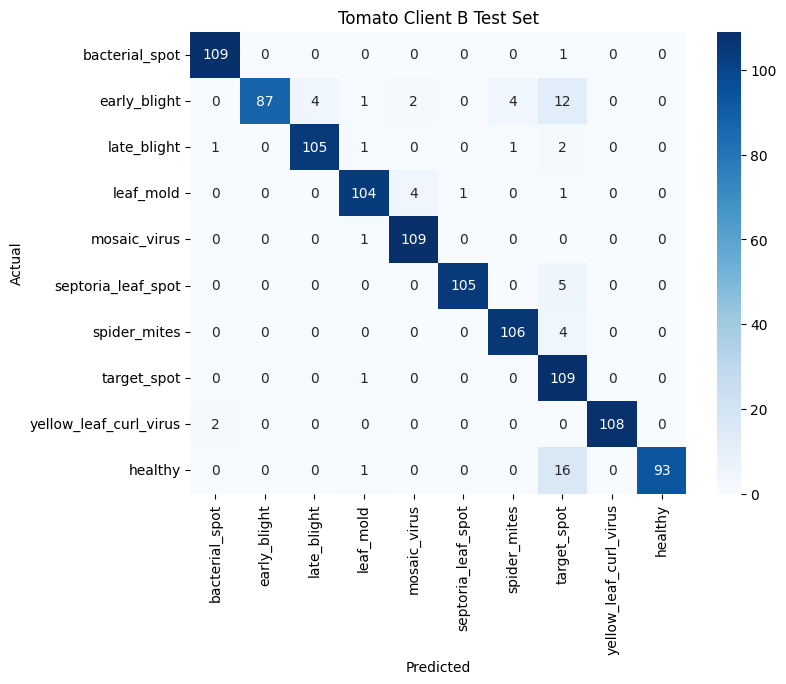

In [49]:
print("\n================ TOMATO CLIENT B TEST ================")

report_B, conf_B, auc_B = evaluate_model(tomato_model_B, test_loader_B)

print(report_B)
print("AUROC:", auc_B)

plot_confusion_matrix(conf_B, "Tomato Client B Test Set", tomato_id_to_label)


================ TOMATO UNSEEN TEST (Ensemble Head) ================
              precision    recall  f1-score   support

           0     0.9338    0.9842    0.9583       444
           1     0.9443    0.8018    0.8672       444
           2     0.8860    0.9099    0.8978       444
           3     0.9197    0.9032    0.9114       444
           4     0.9386    0.9977    0.9672       444
           5     0.8835    0.9392    0.9105       444
           6     0.9416    0.9797    0.9603       444
           7     0.7869    0.9977    0.8798       444
           8     1.0000    0.9820    0.9909       444
           9     1.0000    0.6712    0.8032       444

    accuracy                         0.9167      4440
   macro avg     0.9234    0.9167    0.9147      4440
weighted avg     0.9234    0.9167    0.9147      4440

AUROC: 0.9932585175265356


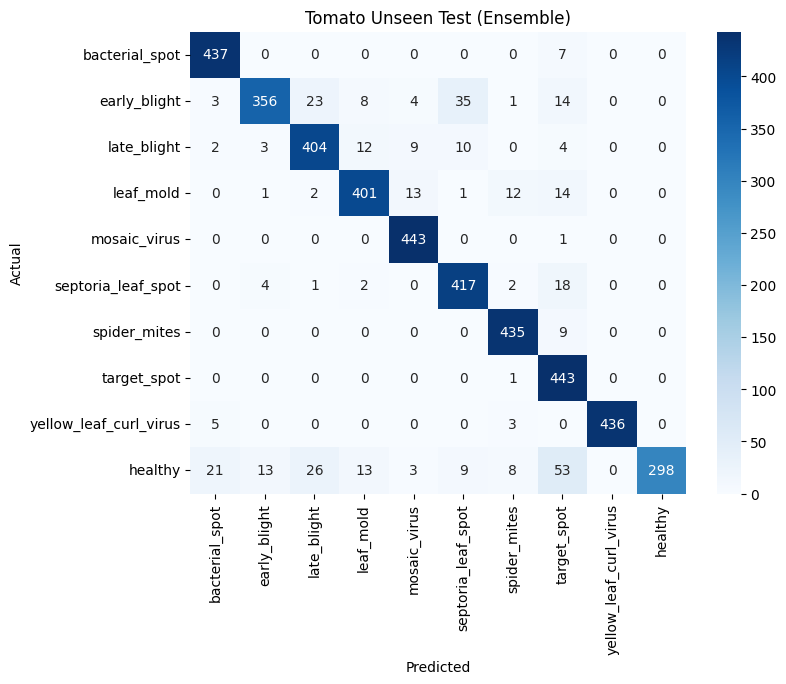

In [45]:
print("\n================ TOMATO UNSEEN TEST (Ensemble Head) ================")

tomato_ens_model = ClientModel(num_classes=NUM_TOMATO_CLASSES, pretrained=False).to(device)
tomato_ens_model.feature_extractor.load_state_dict(tomato_model_A.feature_extractor.state_dict())
tomato_ens_model.classifier.load_state_dict(tomato_ensemble_head.state_dict())

report_U, conf_U, auc_U = evaluate_model(tomato_ens_model, unseen_tomato_loader)

print(report_U)
print("AUROC:", auc_U)

plot_confusion_matrix(conf_U, "Tomato Unseen Test (Ensemble)", tomato_id_to_label)

Corn Evaluation


================ CORN CLIENT A TEST ================
              precision    recall  f1-score   support

           0     0.9623    0.8947    0.9273       114
           1     0.9627    0.9923    0.9773       130
           2     0.8644    0.8793    0.8718        58
           3     0.9750    1.0000    0.9873       117

    accuracy                         0.9523       419
   macro avg     0.9411    0.9416    0.9409       419
weighted avg     0.9524    0.9523    0.9519       419

AUROC: 0.9955165288945562


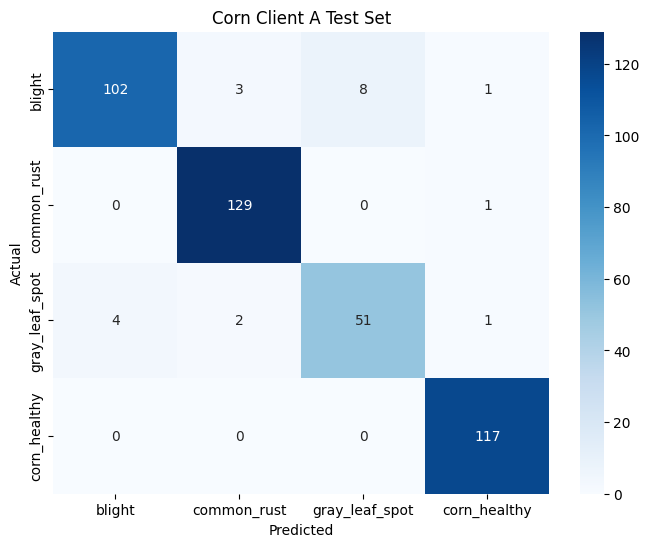

In [50]:
print("\n================ CORN CLIENT A TEST ================")

report_CA, conf_CA, auc_CA = evaluate_model(corn_model_A, test_loader_CA)

print(report_CA)
print("AUROC:", auc_CA)

plot_confusion_matrix(conf_CA, "Corn Client A Test Set", corn_id_to_label)


================ CORN CLIENT B TEST ================
              precision    recall  f1-score   support

           0     0.9333    0.9899    0.9608        99
           1     1.0000    1.0000    1.0000       120
           2     0.9756    0.7843    0.8696        51
           3     0.9667    1.0000    0.9831       116

    accuracy                         0.9689       386
   macro avg     0.9689    0.9436    0.9534       386
weighted avg     0.9697    0.9689    0.9676       386

AUROC: 0.9985066005751674


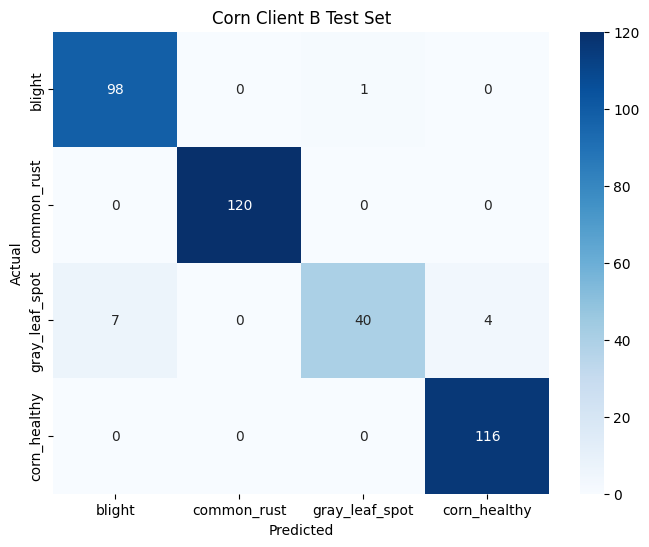

In [51]:
print("\n================ CORN CLIENT B TEST ================")

report_CB, conf_CB, auc_CB = evaluate_model(corn_model_B, test_loader_CB)

print(report_CB)
print("AUROC:", auc_CB)

plot_confusion_matrix(conf_CB, "Corn Client B Test Set", corn_id_to_label)


================ CORN UNSEEN TEST (Ensemble Head) ================
              precision    recall  f1-score   support

           0     0.9370    0.9502    0.9435      1908
           1     0.9607    0.9990    0.9794      1907
           2     0.9392    0.8368    0.8850      1642
           3     0.9607    1.0000    0.9800      1859

    accuracy                         0.9501      7316
   macro avg     0.9494    0.9465    0.9470      7316
weighted avg     0.9497    0.9501    0.9490      7316

AUROC: 0.9957723210959929


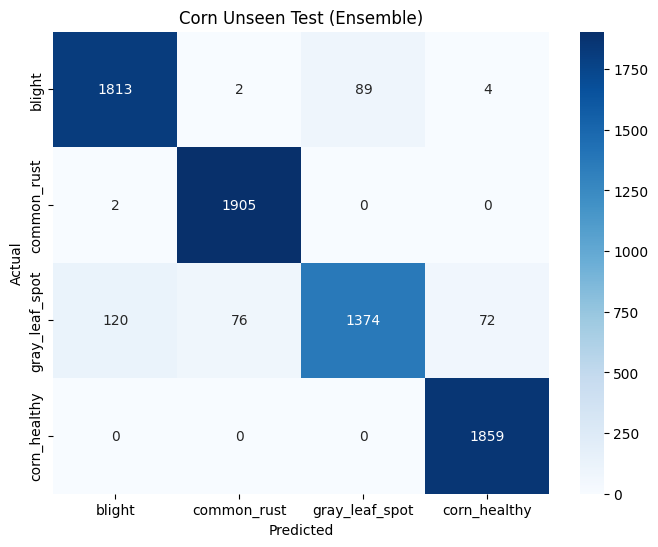

In [48]:
print("\n================ CORN UNSEEN TEST (Ensemble Head) ================")

corn_ens_model = ClientModel(num_classes=NUM_CORN_CLASSES, pretrained=False).to(device)
corn_ens_model.feature_extractor.load_state_dict(corn_model_A.feature_extractor.state_dict())
corn_ens_model.classifier.load_state_dict(corn_ensemble_head.state_dict())

report_CU, conf_CU, auc_CU = evaluate_model(corn_ens_model, unseen_corn_loader)

print(report_CU)
print("AUROC:", auc_CU)

plot_confusion_matrix(conf_CU, "Corn Unseen Test (Ensemble)", corn_id_to_label)